In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
from qiskit_device_benchmarking.bench_code.mrb import MirrorRB, QuantumAwesomeness


# custom noisy backend (or an attempt at one, at least)
class NoisyBackend(GenericBackendV2):
    def __init__(
        self,
        num_qubits: int,
        basis_gates: list[str] | None = None,
        coupling_map: list[list[int]] = None,
        p1: float = 0,
        p2: float = 0,
    ):
        self.p = (p1,p2)
        super().__init__(
            num_qubits,
            basis_gates,
            coupling_map=coupling_map,
            noise_info = (p1>0 or p2 >0)
            )
    def _get_noise_defaults(self, name: str, num_qubits: int) -> tuple:
        if name in ['delay', 'reset']:
            return (self.p[0],self.p[0])
        else:
            if num_qubits == 1:
                return (0,0,self.p[0],self.p[0])
            else:
                return (0,0,self.p[1],self.p[1])


We'll look at Quantum Awesomeness on either a real 127 qubit device, or a small emulated backend.

In [2]:
real_device = False

if real_device:
    from qiskit_ibm_provider import IBMProvider
    provider = IBMProvider(instance="ibm-q/open/main")
    backend = provider.get_backend('ibm_sherbrooke')
else:
    p = 1e-2
    backend = NoisyBackend(
    num_qubits=4,
    basis_gates = ["id", "h", "x", "y", "z", "rx", "cx"],
    p1=p/10,
    p2=p,
    )

First we set up the experiment. 

Some notes on parameters:
* `range(backend.num_qubits)`: We use the whole device.
* `two_qubit_gate_density=0.25`: Having around half of all qubits involved in an entangling gate seems like a good fraction, and this makes that happen.
* `initial_entangling_angle=np.pi/2`: Default angle is `np.pi/2`, which creates maximally entangled pairs. We'll use `np.pi/2` so we can more easily see the gates when looking at the circuits.
* `num_samples=20`: Number of different sets of random Clifford circuits.

In [3]:
# number of shots per circuit

from qiskit_device_benchmarking.bench_code.mrb import MirrorRB, QuantumAwesomeness

shots = 10000

# lengths of different mirror circuits to run
lengths = [2]+[4,10,20,50,100]

# set up the experiment object
exp = MirrorRB(
    range(backend.num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=5,
    seed=123,
    initial_entangling_angle=np.pi/4,
    final_entangling_angle=0,
    )
exp.set_run_options(
    shots=shots,
    #seed_simulator=123
)



Now we run it!

In [4]:
#run
rb_data = exp.run()
print(rb_data.job_ids)

['5d9a9701-da37-4e09-a7a9-d7c76198408d']


To see what circuits were run, don't use `exp.circuits()` because that will set up a new bunch of circuits. Instead use `exp._static_trans_circuits`, which stores the transpiled circuits that were run.

There are two differences between MQA circuits and MRB circuits:
* MQA places the new layers of the sequence at the beginning and end, whereas MRB places them in the middle.
* MQA inserts `rx` gates on the control qubit of any qubit involved in a CX in the first layer. Leading to entanglement for all pairs involved in a CX in the first layer.

To see what pairs were used for the CX gates in the first layer of each circuit, use `exp._pairs`.

Below are the first two lengths of circuit for the first sequence of random Cliffords. The `Rx(π/4)` gates here are those inserted to create the entangled pairs.

In [5]:
print('Pairs:', exp._pairs[0])
exp._static_trans_circuits[0].draw(fold=-1)

Pairs: [(0, 1), (3, 2)]


global phase: 7π/4
           ┌───┐   ┌─────────┐┌───┐┌───┐ ░      ┌─────────┐ ░       ░    ┌───┐   ┌─────────┐┌───┐┌───┐ ░       ░       ░ ┌───┐┌─────────┐ ┌───┐┌───┐ ░  ░ ┌─┐         
   q_0: ───┤ H ├───┤ Rx(π/2) ├┤ H ├┤ Y ├─░───■──┤ Rx(π/4) ├─░───■───░────┤ H ├───┤ Rx(π/2) ├┤ H ├┤ Y ├─░───■───░───■───░─┤ H ├┤ Rx(π/2) ├─┤ H ├┤ Y ├─░──░─┤M├─────────
           ├───┤   └─────────┘└───┘└───┘ ░ ┌─┴─┐└─────────┘ ░ ┌─┴─┐ ░    ├───┤   └─────────┘└───┘└───┘ ░ ┌─┴─┐ ░ ┌─┴─┐ ░ ├───┤└─────────┘ └───┘└───┘ ░  ░ └╥┘┌─┐      
   q_1: ───┤ H ├─────────────────────────░─┤ X ├────────────░─┤ X ├─░────┤ H ├─────────────────────────░─┤ X ├─░─┤ X ├─░─┤ H ├───────────────────────░──░──╫─┤M├──────
        ┌──┴───┴──┐   ┌───┐              ░ ├───┤            ░ ├───┤ ░ ┌──┴───┴──┐   ┌───┐              ░ ├───┤ ░ ├───┤ ░ ├───┤┌──────────┐           ░  ░  ║ └╥┘┌─┐   
   q_2: ┤ Rx(π/2) ├───┤ H ├──────────────░─┤ X ├────────────░─┤ X ├─░─┤ Rx(π/2) ├───┤ H ├──────────────░─┤ X ├─░─┤ X ├─░─┤ H ├┤ Rx(-π/2) ├───────────░──░──╫──╫─┤M├───
        └──┬───┬──┘┌──┴───┴──┐┌───┐      ░ └─┬─┘┌─────────┐ ░ └─┬─┘ ░ └──┬───┬──┘┌──┴───┴──┐┌───┐      ░ └─┬─┘ ░ └─┬─┘ ░ ├───┤├─────────┬┘┌───┐┌───┐ ░  ░  ║  ║ └╥┘┌─┐
   q_3: ───┤ H ├───┤ Rx(π/2) ├┤ H ├──────░───■──┤ Rx(π/4) ├─░───■───░────┤ H ├───┤ Rx(π/2) ├┤ H ├──────░───■───░───■───░─┤ H ├┤ Rx(π/2) ├─┤ H ├┤ Z ├─░──░──╫──╫──╫─┤M├
           └───┘   └─────────┘└───┘      ░      └─────────┘ ░       ░    └───┘   └─────────┘└───┘      ░       ░       ░ └───┘└─────────┘ └───┘└───┘ ░  ░  ║  ║  ║ └╥┘
meas: 4/═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                                                                                           0  1  2  3

In [6]:
# generate a fresh sequence for one sample/length …
seq = exp._sample_sequences()[0]          # first sample, first length

def layer_desc(layer):
    """Return a short description of a layer’s gates."""
    desc = []
    for elem in layer:
        # GenericClifford produces integers when sampled
        if isinstance(elem, int):
            desc.append(f"Clifford({elem})")
        else:
            # GenericPauli / two‑qubit gates etc.
            op = getattr(elem, "op", elem)
            desc.append(op.__class__.__name__)
    return " + ".join(desc)

for idx, layer in enumerate(seq):
    print(f"layer {idx:2d}: {layer_desc(layer)}")

# now draw the corresponding circuit so you can compare
print("\ntranspiled circuit:")
exp._sequences_to_circuits([seq])[0].draw(fold=-1)

layer  0: int + int + int + int
layer  1: _SingletonCXGate + _SingletonCXGate
layer  2: _SingletonCXGate + _SingletonCXGate
layer  3: int + int + int + int
layer  4: _SingletonCXGate + _SingletonCXGate
layer  5: _SingletonCXGate + _SingletonCXGate
layer  6: int32 + int32 + int32 + int32

transpiled circuit:


┌─────────────────┐ ░      ┌─────────┐ ░       ░ ┌─────────────────┐ ░       ░       ░ ┌─────────────────┐ ░  ░ ┌─┐         
   q_0: ┤ Clifford-1Q(16) ├─░───■──┤ Rx(π/4) ├─░───■───░─┤ Clifford-1Q(16) ├─░───■───░───■───░─┤ Clifford-1Q(16) ├─░──░─┤M├─────────
        └┬────────────────┤ ░ ┌─┴─┐└─────────┘ ░ ┌─┴─┐ ░ └┬────────────────┤ ░ ┌─┴─┐ ░ ┌─┴─┐ ░ └┬────────────────┤ ░  ░ └╥┘┌─┐      
   q_1: ─┤ Clifford-1Q(1) ├─░─┤ X ├────────────░─┤ X ├─░──┤ Clifford-1Q(1) ├─░─┤ X ├─░─┤ X ├─░──┤ Clifford-1Q(1) ├─░──░──╫─┤M├──────
         ├────────────────┤ ░ ├───┤            ░ ├───┤ ░  ├────────────────┤ ░ ├───┤ ░ ├───┤ ░  ├────────────────┤ ░  ░  ║ └╥┘┌─┐   
   q_2: ─┤ Clifford-1Q(5) ├─░─┤ X ├────────────░─┤ X ├─░──┤ Clifford-1Q(5) ├─░─┤ X ├─░─┤ X ├─░──┤ Clifford-1Q(3) ├─░──░──╫──╫─┤M├───
         ├────────────────┤ ░ └─┬─┘┌─────────┐ ░ └─┬─┘ ░  ├────────────────┤ ░ └─┬─┘ ░ └─┬─┘ ░ ┌┴────────────────┤ ░  ░  ║  ║ └╥┘┌─┐
   q_3: ─┤ Clifford-1Q(4) ├─░───■──┤ Rx(π/4) ├─░───■───░──┤ Clifford-1Q(4) ├─░───■───░───■───░─┤ Clifford-1Q(22) ├─░──░──╫──╫──╫─┤M├
         └────────────────┘ ░      └─────────┘ ░       ░  └────────────────┘ ░       ░       ░ └─────────────────┘ ░  ░  ║  ║  ║ └╥┘
meas: 4/═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                                                         0  1  2  3

In [7]:
print('Pairs:', exp._pairs[1])
exp._static_trans_circuits[1].draw(fold=-1)

Pairs: [(2, 0)]


global phase: 3π/4
           ┌───┐   ┌─────────┐┌───┐┌───┐ ░ ┌───┐                                 ░       ░       ░ ┌───┐                           ░    ┌───┐   ┌─────────┐┌───┐┌───┐ ░      ┌───┐                 ░       ░       ░      ┌───┐                 ░ ┌───┐┌─────────┐ ┌───┐┌───┐ ░  ░ ┌─┐         
   q_0: ───┤ H ├───┤ Rx(π/2) ├┤ H ├┤ Y ├─░─┤ X ├─────────────────────────────────░───■───░───■───░─┤ X ├───────────────────────────░────┤ H ├───┤ Rx(π/2) ├┤ H ├┤ Y ├─░──────┤ X ├─────────────────░───■───░───■───░──────┤ X ├─────────────────░─┤ H ├┤ Rx(π/2) ├─┤ H ├┤ Y ├─░──░─┤M├─────────
           ├───┤   └─────────┘└───┘└───┘ ░ └─┬─┘   ┌───┐   ┌─────────┐┌───┐┌───┐ ░ ┌─┴─┐ ░ ┌─┴─┐ ░ └─┬─┘┌───┐┌─────────┐┌───┐┌───┐ ░    ├───┤   └─────────┘└───┘└───┘ ░ ┌───┐└─┬─┘┌─────────┐┌───┐ ░ ┌─┴─┐ ░ ┌─┴─┐ ░ ┌───┐└─┬─┘┌─────────┐┌───┐ ░ ├───┤└─────────┘ └───┘└───┘ ░  ░ └╥┘┌─┐      
   q_1: ───┤ H ├─────────────────────────░───┼─────┤ H ├───┤ Rx(π/2) ├┤ H ├┤ Z ├─░─┤ X ├─░─┤ X ├─░───┼──┤ H ├┤ Rx(π/2) ├┤ H ├┤ Z ├─░────┤ H ├─────────────────────────░─┤ H ├──┼──┤ Rx(π/2) ├┤ H ├─░─┤ X ├─░─┤ X ├─░─┤ H ├──┼──┤ Rx(π/2) ├┤ H ├─░─┤ H ├───────────────────────░──░──╫─┤M├──────
        ┌──┴───┴──┐   ┌───┐              ░   │  ┌──┴───┴──┐└─────────┘└───┘└───┘ ░ ├───┤ ░ ├───┤ ░   │  └───┘└─────────┘└───┘└───┘ ░ ┌──┴───┴──┐   ┌───┐              ░ └───┘  │  └─────────┘└───┘ ░ ├───┤ ░ ├───┤ ░ └───┘  │  └─────────┘└───┘ ░ ├───┤┌──────────┐           ░  ░  ║ └╥┘┌─┐   
   q_2: ┤ Rx(π/2) ├───┤ H ├──────────────░───■──┤ Rx(π/4) ├──────────────────────░─┤ X ├─░─┤ X ├─░───■─────────────────────────────░─┤ Rx(π/2) ├───┤ H ├──────────────░────────■───────────────────░─┤ X ├─░─┤ X ├─░────────■───────────────────░─┤ H ├┤ Rx(-π/2) ├───────────░──░──╫──╫─┤M├───
        └──┬───┬──┘┌──┴───┴──┐┌───┐      ░ ┌───┐└─────────┘                      ░ └─┬─┘ ░ └─┬─┘ ░ ┌───┐                           ░ └──┬───┬──┘┌──┴───┴──┐┌───┐      ░ ┌───┐                      ░ └─┬─┘ ░ └─┬─┘ ░ ┌───┐                      ░ ├───┤├─────────┬┘┌───┐┌───┐ ░  ░  ║  ║ └╥┘┌─┐
   q_3: ───┤ H ├───┤ Rx(π/2) ├┤ H ├──────░─┤ X ├─────────────────────────────────░───■───░───■───░─┤ X ├───────────────────────────░────┤ H ├───┤ Rx(π/2) ├┤ H ├──────░─┤ X ├──────────────────────░───■───░───■───░─┤ X ├──────────────────────░─┤ H ├┤ Rx(π/2) ├─┤ H ├┤ Z ├─░──░──╫──╫──╫─┤M├
           └───┘   └─────────┘└───┘      ░ └───┘                                 ░       ░       ░ └───┘                           ░    └───┘   └─────────┘└───┘      ░ └───┘                      ░       ░       ░ └───┘                      ░ └───┘└─────────┘ └───┘└───┘ ░  ░  ║  ║  ║ └╥┘
meas: 4/════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                                                                                                                                                                                                                    0  1  2  3

In [8]:
exp._sequences_to_circuits([exp._sample_sequences()[1]])[0].draw(fold=-1)

┌─────────────────┐ ░       ┌───┐                           ░       ░       ░       ┌───┐                           ░ ┌─────────────────┐ ░                   ┌───┐ ░       ░       ░                   ┌───┐ ░ ┌─────────────────┐ ░  ░ ┌─┐         
   q_0: ┤ Clifford-1Q(16) ├─░───────┤ X ├───────────────────────────░───■───░───■───░───────┤ X ├───────────────────────────░─┤ Clifford-1Q(16) ├─░───────────────────┤ X ├─░───■───░───■───░───────────────────┤ X ├─░─┤ Clifford-1Q(16) ├─░──░─┤M├─────────
        └┬────────────────┤ ░       └─┬─┘       ┌─────────────────┐ ░ ┌─┴─┐ ░ ┌─┴─┐ ░       └─┬─┘       ┌─────────────────┐ ░ └┬────────────────┤ ░ ┌────────────────┐└─┬─┘ ░ ┌─┴─┐ ░ ┌─┴─┐ ░ ┌────────────────┐└─┬─┘ ░ └┬────────────────┤ ░  ░ └╥┘┌─┐      
   q_1: ─┤ Clifford-1Q(1) ├─░─────────┼─────────┤ Clifford-1Q(22) ├─░─┤ X ├─░─┤ X ├─░─────────┼─────────┤ Clifford-1Q(22) ├─░──┤ Clifford-1Q(1) ├─░─┤ Clifford-1Q(4) ├──┼───░─┤ X ├─░─┤ X ├─░─┤ Clifford-1Q(4) ├──┼───░──┤ Clifford-1Q(1) ├─░──░──╫─┤M├──────
         ├────────────────┤ ░         │         └───┬─────────┬───┘ ░ ├───┤ ░ ├───┤ ░         │         └─────────────────┘ ░  ├────────────────┤ ░ └────────────────┘  │   ░ ├───┤ ░ ├───┤ ░ └────────────────┘  │   ░  ├────────────────┤ ░  ░  ║ └╥┘┌─┐   
   q_2: ─┤ Clifford-1Q(5) ├─░─────────■─────────────┤ Rx(π/4) ├─────░─┤ X ├─░─┤ X ├─░─────────■─────────────────────────────░──┤ Clifford-1Q(5) ├─░─────────────────────■───░─┤ X ├─░─┤ X ├─░─────────────────────■───░──┤ Clifford-1Q(3) ├─░──░──╫──╫─┤M├───
         ├────────────────┤ ░ ┌────────────────┐    └─────────┘     ░ └─┬─┘ ░ └─┬─┘ ░ ┌────────────────┐                    ░  ├────────────────┤ ░ ┌────────────────┐      ░ └─┬─┘ ░ └─┬─┘ ░ ┌────────────────┐      ░ ┌┴────────────────┤ ░  ░  ║  ║ └╥┘┌─┐
   q_3: ─┤ Clifford-1Q(4) ├─░─┤ Clifford-1Q(6) ├────────────────────░───■───░───■───░─┤ Clifford-1Q(6) ├────────────────────░──┤ Clifford-1Q(4) ├─░─┤ Clifford-1Q(6) ├──────░───■───░───■───░─┤ Clifford-1Q(6) ├──────░─┤ Clifford-1Q(22) ├─░──░──╫──╫──╫─┤M├
         └────────────────┘ ░ └────────────────┘                    ░       ░       ░ └────────────────┘                    ░  └────────────────┘ ░ └────────────────┘      ░       ░       ░ └────────────────┘      ░ └─────────────────┘ ░  ░  ║  ║  ║ └╥┘
meas: 4/══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                                                                                                                                                                                  0  1  2  3

In [9]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
#exp.analysis.set_options(analyzed_quantity='Mutual Information')
analysis = exp.analysis.run(rb_data)

Then plot the results.

Note: if you get the `'Figure index 0 out of range.'` error, it might be because the analysis is still running in the background. So just try again.

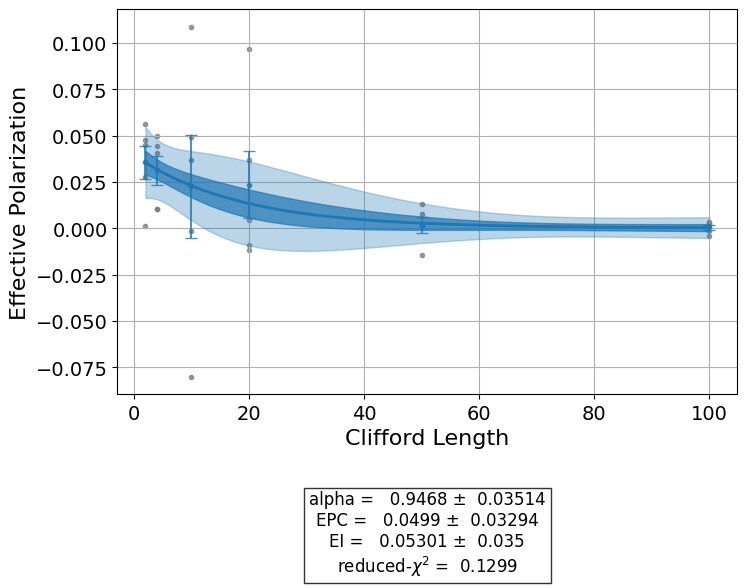

In [11]:
analysis.figure(0)

When we calculate the mutual informations, it is done by the `QuantumAwesomeness` object. We can also use this directly.

In [ ]:
qa = QuantumAwesomeness(exp.backend.coupling_map)

It can be used to calculate the MIs for each pair in the coupling map for each circuit that was run.

In [ ]:
mi = qa.mutual_info(rb_data.data())

It can also be used to calculate the mean MIs, where separate means are taken for the entangled pairs and the non-entangled pairs.

In [ ]:
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(3)]
yerrs = [[],[],[]]

for p, pairtype in enumerate(['paired', 'unpaired', 'singles']):
    for j,m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j%6].append(m)
    for j in range(6):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='unpaired')
plt.errorbar(lengths,ys[2],yerr=yerrs[2],label='singles')
plt.yscale('log')
plt.legend()

Pickled results from a run on `'ibm_sherbrooke'`can be found in the following files.

* `exp`: `'pickled_sherbrooke/exp_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `data`: `'pickled_sherbrooke/data_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `data.data()`: `'pickled_sherbrooke/data_data_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `mi`: `'pickled_sherbrooke/mi_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`



In [13]:
# show the rb_data object itself
print(rb_data)

# get the raw payload
data_entries = rb_data.data()

# print the number of entries and the first five
print("total entries:", len(data_entries))
for i, entry in enumerate(data_entries[0:1]):          # top‑5
    print(f"\nentry {i}:")
    print(entry)

# if you want to pretty‑print json‑like structures, use pprint
from pprint import pprint
pprint(data_entries[0:1])

---------------------------------------------------
Experiment: MirrorRB
Experiment ID: d8af3868-6d1e-41be-8cd1-101adf7b0b79
Status: ExperimentStatus.DONE
Backend: <__main__.NoisyBackend object at 0x000002056F9B6AD0>
Data: 30
Analysis Results: 3
Figures: 1
Artifacts: 2
total entries: 30

entry 0:
{'job_id': '5d9a9701-da37-4e09-a7a9-d7c76198408d', 'meas_level': 2, 'meas_return': 'single', 'counts': {'0111': 1738, '0101': 1651, '0001': 1687, '0011': 1773, '1101': 344, '0100': 351, '0110': 395, '0010': 361, '1011': 355, '1111': 349, '1000': 70, '0000': 359, '1010': 66, '1001': 352, '1110': 68, '1100': 81}, 'memory': ['0111', '0111', '0101', '0001', '0101', '0101', '0001', '0001', '0011', '1101', '0011', '0100', '0011', '0101', '0111', '0101', '0011', '0111', '0110', '0111', '0010', '0001', '1011', '0001', '0101', '0001', '0001', '0111', '1111', '0101', '0001', '0001', '0111', '0100', '0110', '1000', '0111', '0110', '0011', '0000', '0111', '0001', '0111', '1111', '0111', '1010', '1111', '0

In [12]:
# show the entire structure at once
print(exp._pairs)

# or loop through it with an index
for idx, pairs in enumerate(exp._pairs):
    print(f"sequence {idx}: {pairs}")

# if you only care about the first few entries
from itertools import islice
for idx, pairs in enumerate(islice(exp._pairs, 5)):
    print(f"{idx}: {pairs}")

[[(0, 1), (3, 2)], [(2, 0)], [(3, 1), (0, 2)], [(2, 1), (3, 0)], [(3, 1), (2, 0)], [(1, 3)], [(2, 1)], [], [(0, 3)], [(2, 0)], [(3, 2), (0, 1)], [], [(1, 2)], [(2, 1)], [(3, 2)], [(2, 1), (0, 3)], [], [(1, 0)], [(2, 1), (3, 0)], [], [(1, 2)], [(2, 1), (3, 0)], [(0, 2)], [], [], [], [(1, 0)], [(3, 2)], [(3, 0)], [(2, 1)]]
sequence 0: [(0, 1), (3, 2)]
sequence 1: [(2, 0)]
sequence 2: [(3, 1), (0, 2)]
sequence 3: [(2, 1), (3, 0)]
sequence 4: [(3, 1), (2, 0)]
sequence 5: [(1, 3)]
sequence 6: [(2, 1)]
sequence 7: []
sequence 8: [(0, 3)]
sequence 9: [(2, 0)]
sequence 10: [(3, 2), (0, 1)]
sequence 11: []
sequence 12: [(1, 2)]
sequence 13: [(2, 1)]
sequence 14: [(3, 2)]
sequence 15: [(2, 1), (0, 3)]
sequence 16: []
sequence 17: [(1, 0)]
sequence 18: [(2, 1), (3, 0)]
sequence 19: []
sequence 20: [(1, 2)]
sequence 21: [(2, 1), (3, 0)]
sequence 22: [(0, 2)]
sequence 23: []
sequence 24: []
sequence 25: []
sequence 26: [(1, 0)]
sequence 27: [(3, 2)]
sequence 28: [(3, 0)]
sequence 29: [(2, 1)]
0: [(

In [ ]:
# demonstration of backend randomness vs sequence seeding
# make a fresh experiment object so we can tweak options
exp_demo = MirrorRB(
    range(backend.num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=5,
    seed=123,
    initial_entangling_angle=np.pi/4,
    final_entangling_angle=0,
)

exp_demo.set_run_options(shots=shots)

# run once so that _static_trans_circuits is populated (mirrors earlier usage)
_ = exp_demo.run()

# the circuit sets are deterministic
circs1 = exp_demo._static_trans_circuits
circs2 = exp_demo._static_trans_circuits
print("same circuits object?", circs1 is circs2)

exp_demo.set_run_options(shots=shots, seed_simulator=123)
edataC = exp_demo.run()
exp_demo.set_run_options(shots=shots, seed_simulator=123)
edataD = exp_demo.run()
print("data identical (with seed_simulator)?", edataC.data() == edataD.data())
